In [2]:
from pathlib import Path
import pandas as pd

import os
os.chdir(r"C:\Users\jonah\Desktop\personalProjects\temp_electricity\src\reading_cleaning")

from read_elec_parquet import read_parquet_range

import matplotlib.pyplot as plt

In [ ]:
## Read in Dataframe
df1 = read_parquet_range(
    2025, 1,
    2025, 1
)

Reading 202501...
Reading 202502...
Reading 202503...
Reading 202504...
Reading 202505...
Reading 202506...
Reading 202507...
Reading 202508...
Reading 202509...
Reading 202510...
Reading 202511...
Reading 202512...


In [41]:
## Cleaning
# Convert to datetime
df1['DATE'] = pd.to_datetime(df1['DATE'], format='%Y-%m-%d')
# Drop parent FSA groups (Only have first two chars)
df1 = df1[df1["FSA"].str.len() == 3]
# Split between Residential and SGS
df2 = df1.query("CUSTOMER_TYPE != 'Residential'")
df1 = df1.query("CUSTOMER_TYPE == 'Residential'")

In [42]:
# Creating unweighted average consumption per premise
df1['avg_consumption_unweighted'] = df1['TOTAL_CONSUMPTION'] / df1['PREMISE_COUNT']
df2['avg_consumption_unweighted'] = df2['TOTAL_CONSUMPTION'] / df2['PREMISE_COUNT']

In [43]:
# See FSA Price Plan observation breakdown: RESIDENTIAL
table_res = df1.groupby(["FSA", "PRICE_PLAN"])["PREMISE_COUNT"].mean().unstack(fill_value=0)
display(table_res)

# Single FSA check:
fsa_k0 = (df1[df1["FSA"].str.startswith("K0")]
.groupby(['FSA', 'DATE', 'PRICE_PLAN'])["PREMISE_COUNT"].mean()
.unstack(fill_value=0).reset_index()
)

PRICE_PLAN,Retailer,TOU,Tiered,ULO
FSA,,,,
K0A,520.147717,37778.504944,6844.644635,272.538699
K0B,105.631507,7991.824153,910.325571,44.917808
K0C,293.130023,17790.706215,2370.858447,75.230023
K0E,176.169863,15293.793785,1818.757306,61.969863
K0G,182.095890,16702.494350,2686.597032,87.217808
...,...,...,...,...
P7L,0.000000,435.129224,73.884932,0.000000
P8N,30.203747,2369.363813,205.083562,0.000000
P8T,0.000000,24.314041,0.000000,0.000000


In [39]:
# See FSA Price Plan observation breakdown: SGS
table_sgs = df2.groupby(["FSA", "PRICE_PLAN"])["PREMISE_COUNT"].mean().unstack(fill_value=0)
display(table_sgs)

# Single FSA check:
fsa_k0_sgs = (df2[df2["FSA"].str.startswith("K0")]
.groupby(['FSA', 'DATE', 'PRICE_PLAN'])["PREMISE_COUNT"].mean()
.unstack(fill_value=0).reset_index()
)

PRICE_PLAN,Retailer,TOU,Tiered
FSA,,,
K0A,332.772489,2778.468037,114.811872
K0B,55.473288,679.621461,27.364384
K0C,197.013470,1686.416895,43.799658
K0E,99.795662,1261.332877,27.054566
K0G,127.891781,1400.288242,29.858080
...,...,...,...
P7K,0.000000,59.118379,0.000000
P7L,0.000000,25.000000,0.000000
P8N,34.241096,0.000000,16.883880


In [ ]:
## Compare SGS to Residential for sample FSA


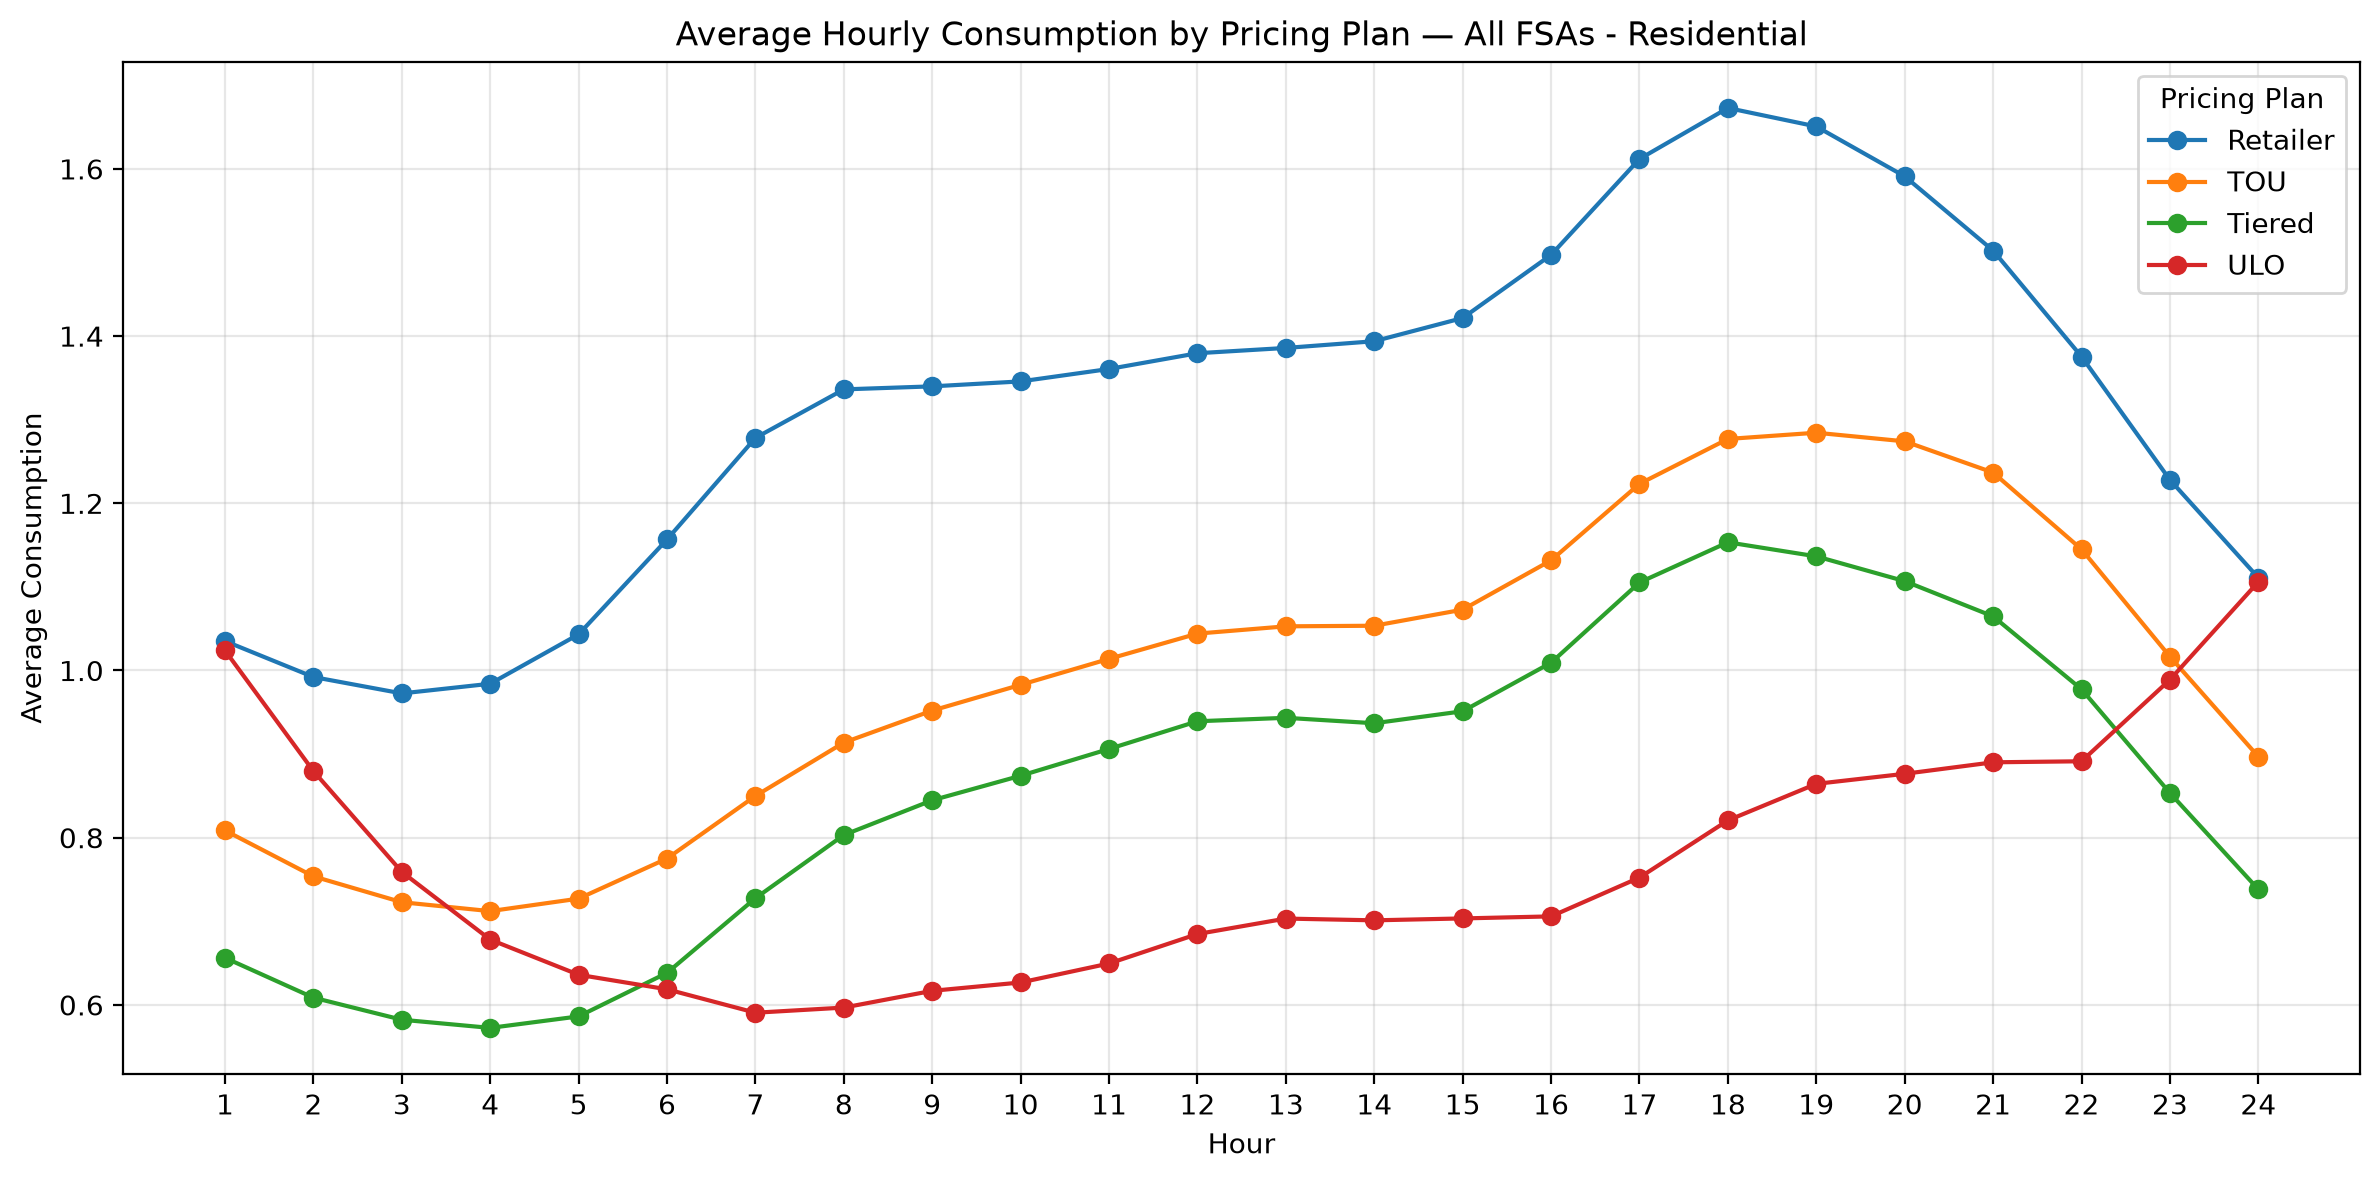

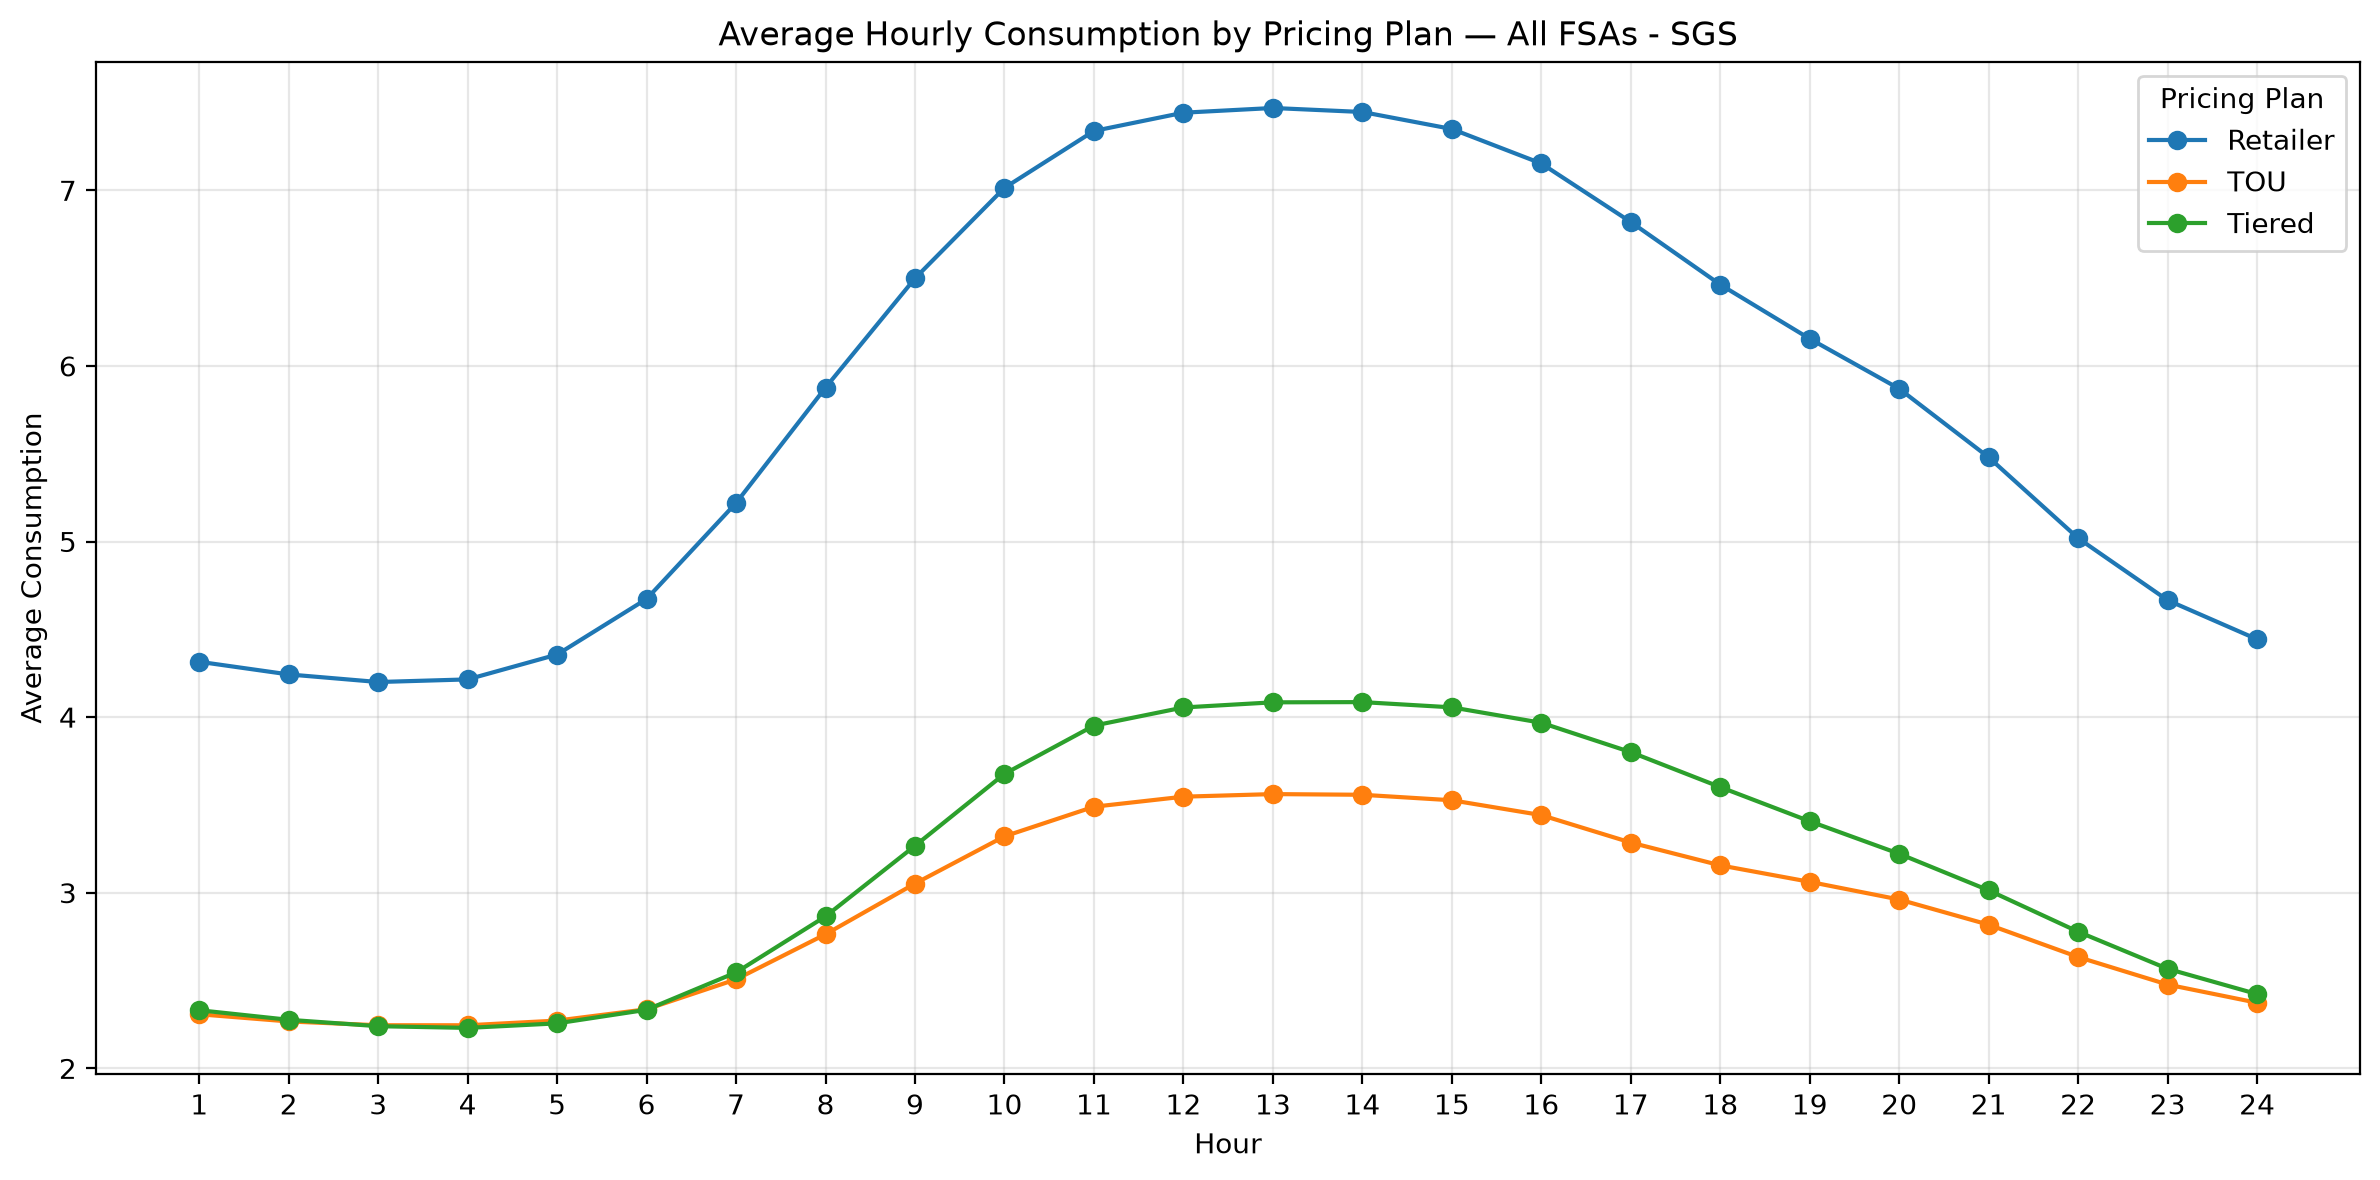

In [21]:
## Graphing average consumption per premise across pricing plans 
# Residential only
consumption_table_res = (
    df1.groupby(['PRICE_PLAN', 'HOUR'])['avg_consumption_unweighted']
      .mean()
      .to_frame(name='CONSUMPTION')
)

plot_df = consumption_table_res.reset_index()
plt.figure(figsize=(12, 6))
for plan, group in plot_df.groupby('PRICE_PLAN'):
    plt.plot(
        group['HOUR'],
        group['CONSUMPTION'],
        marker='o',
        label=str(plan)
    )
plt.xlabel('Hour')
plt.ylabel('Average Consumption')
plt.title('Average Hourly Consumption by Pricing Plan — All FSAs - Residential')
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)

# Explicitly create the legend
plt.legend(
    title='Pricing Plan',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()

# SGS only
consumption_table_sgs = (
    df2.groupby(['PRICE_PLAN', 'HOUR'])['avg_consumption_unweighted']
      .mean()
      .to_frame(name='CONSUMPTION')
)

plot_df = consumption_table_sgs.reset_index()
plt.figure(figsize=(12, 6))
for plan, group in plot_df.groupby('PRICE_PLAN'):
    plt.plot(
        group['HOUR'],
        group['CONSUMPTION'],
        marker='o',
        label=str(plan)
    )
plt.xlabel('Hour')
plt.ylabel('Average Consumption')
plt.title('Average Hourly Consumption by Pricing Plan — All FSAs - SGS')
plt.xticks(range(1, 25))
plt.grid(True, alpha=0.3)

# Explicitly create the legend
plt.legend(
    title='Pricing Plan',
    loc='upper right',
    frameon=True
)

plt.tight_layout()
plt.show()